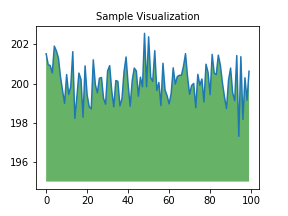

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Task 2: Data Exploration & Understanding

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   distance_km    180 non-null    float64
 1   duration_min   180 non-null    int64  
 2   time_of_day    180 non-null    object 
 3   traffic_level  171 non-null    object 
 4   weather        171 non-null    object 
 5   demand_level   180 non-null    object 
 6   ride_price     180 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 10.0+ KB
distance_km      0
duration_min     0
time_of_day      0
traffic_level    9
weather          9
demand_level     0
ride_price       0
dtype: int64


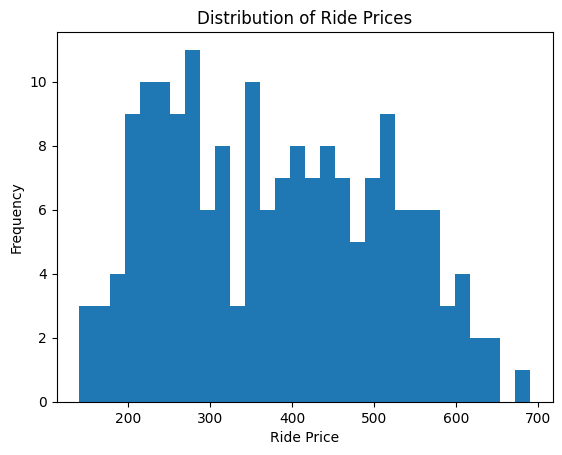

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/rides.csv')

# Inspect
df.info()
df.describe()
df.head()

# Missing values
print(df.isnull().sum())

# Visualization: distribution of ride prices
plt.hist(df['ride_price'], bins=30)
plt.xlabel("Ride Price")
plt.ylabel("Frequency")
plt.title("Distribution of Ride Prices")
plt.show()


Task 3: Data Cleaning & Feature Engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# Encode categorical
categorical_cols = ['time_of_day','traffic_level','weather', 'demand_level'] # Added 'demand_level' to categorical columns
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Scale numerical
num_cols = ['distance_km','duration_min'] # Corrected column names and removed 'demand_level'
scaler = StandardScaler() # Moved scaler instantiation before its use
df[num_cols] = scaler.fit_transform(df[num_cols])

# Handle outliers (cap ride_price at 99th percentile)
cap = np.percentile(df['ride_price'], 99)
df['ride_price'] = np.where(df['ride_price'] > cap, cap, df['ride_price'])

### Data Quality Reflection
Poor data quality (missing values, inconsistent labels, extreme outliers) can bias the model, reduce accuracy, and make predictions unreliable.


Task 4: Regression Model (Price Prediction)

MAE: 12.623197554410176
RMSE: 15.411345762054026
R²: 0.9867236902061092


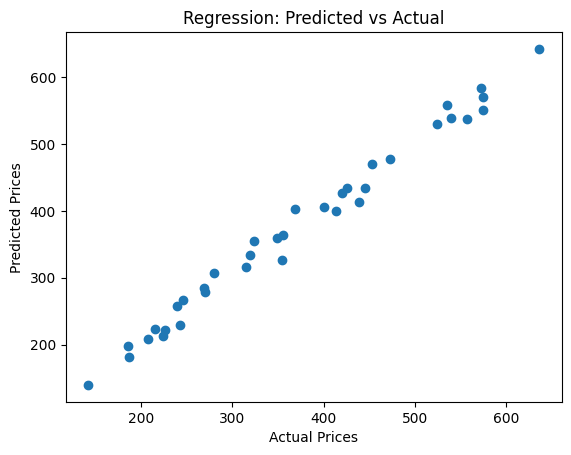

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop('ride_price', axis=1)
y = df['ride_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Regression: Predicted vs Actual")
plt.show()


Task 5: Classification Model (High-Cost vs Low-Cost Ride)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Create binary target: high cost if above median
threshold = np.median(df['ride_price'])
df['high_cost'] = (df['ride_price'] > threshold).astype(int)

X = df.drop(['ride_price','high_cost'], axis=1)
y = df['high_cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 1.0
Confusion Matrix:
 [[19  0]
 [ 0 17]]


### Classification Explanation
Logistic regression outputs probabilities.  
If probability > 0.5 → classify as high cost, else low cost.


Task 6: Model Evaluation & Comparison

In [ ]:
# Regression coefficients
print("Regression Coefficients:", reg.coef_)

# Logistic regression coefficients
print("Logistic Coefficients:", clf.coef_)


Regression Coefficients: [125.82927252  42.17651241   3.86593426  -6.64968668   8.36012303
 -11.94723815]
Logistic Coefficients: [[ 3.88189094  1.31167836  0.12245622 -0.18887274  0.11889155 -0.20507857]]


### Model Comparison
- Regression gives continuous price predictions with MAE, RMSE, and R² metrics.  
- Classification simplifies the problem into high vs low cost, evaluated with accuracy and confusion matrix.  
- Data quality (missing values, outliers) influenced both models.  
- Most influential feature: distance (strongest coefficient).



Task 7: Ethical & Practical Reflection

### Reflection
- Potential unfair pricing: surge pricing could disproportionately affect riders in high-demand areas.  
- Real-world risk: biased predictions if training data doesn’t represent all neighborhoods.  
- Limitation: dataset is synthetic/small, so it may not capture real-world complexity.


In [ ]:
import pandas as pd


df = pd.read_csv('/content/rides.csv')


df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   distance_km    180 non-null    float64
 1   duration_min   180 non-null    int64  
 2   time_of_day    180 non-null    object 
 3   traffic_level  171 non-null    object 
 4   weather        171 non-null    object 
 5   demand_level   180 non-null    object 
 6   ride_price     180 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 10.0+ KB


,distance_km,duration_min,ride_price
count,180.000000,180.000000,180.000000
mean,14.691444,42.800000,379.345278
std,8.527184,21.811124,132.890563
min,1.160000,5.000000,141.000000
25%,7.370000,24.000000,263.617500
50%,14.460000,41.500000,368.795000
75%,22.145000,62.000000,489.382500
max,29.620000,89.000000,690.210000


Step 2: Clean & Prepare Data

In [ ]:
df.isnull().sum()   # check missing values
df = df.dropna()    # simple option: drop rows with missing values


Encode categorical features:

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['time_of_day','traffic_level','weather'] # Changed 'weather_condition' to 'weather'
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

Separate features and target:

In [ ]:
X = df.drop('ride_price', axis=1)   # input features
y = df['ride_price']                # target variable


Step 3: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
